# Task 1
The main business problem is to understand why customers are leaving the company. We need to identify the factors and patterns that may be causing customers to churn, so the company can take steps to retain them.

# Task 2
Useless Predictors
Gender: Gender does not provide a clear or meaningful reason for why a customer would leave the company.
Partner: Whether a customer has a partner does not directly explain their decision to stay with or leave the company.
Useful Predictors
Contract: The type of contract can affect churn because customers with short-term or month-to-month contracts may be more likely to leave.
Tenure: Customers who have been with the company for a shorter time may be more likely to churn than long-term customers.
Internet service: The type of internet service a customer uses may influence their satisfaction and decision to stay or leave.
Online Backup: Customers who use additional services like online backup may be more connected to the company and less likely to churn.
Online security: Having online security services can increase customer engagement and may reduce the chances of customers leaving.

# Task 3
Question:
What are the main reasons why customers decide to leave the company?
What services or improvements can the company provide to increase customer satisfaction and encourage them to stay?

# Task 4
4. How many customers and how many features are in this dataset? List the numerical features and the 
categorical features separately.

There are 20 features and 7043 customers in the dataset.

Numerical features: Tenure, Monthly Charges, Total Charges

Categorical features: Gender, Senior Citizen, Partner, Dependents, Phone service, Multiple Lines, Online security, Online Backup, Device protection, Tech Support, Streaming TV, Streaming movies, Contract, Paperless
billing, Payment Method, Churn


# Task 5
5. Identify any column(s) that are simply identifiers rather than predictive features, and any column(s) whose data type looks wrong for what it represents.

Identifiers: Customer_id, Gender, Senior Citizen, Partner.
Column with wrong datatype: Total Charges. The amount charged to the customers should be numerical but its object.

In [4]:
# Task 6
import pandas as pd
df=pd.read_csv("Telco-customer-churn.csv")
print("Gender")
print(df["gender"].unique())
print("Contract")
print(df["Contract"].unique())
print("Payment Method")
print(df["PaymentMethod"].unique())

# None of these columns contain Unexpected Values.

Gender
<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
Contract
<ArrowStringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str
Payment Method
<ArrowStringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str


In [4]:
import pandas as pd

df=pd.read_csv("Telco-customer-churn.csv")
print(df)
print(df.info)

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL             No  ...   
1        

In [9]:
df.head()
df.dtypes


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [42]:
# Task 7
print(df.isnull().sum())
print(df.isnull().mean()*100)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
customerID          0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64


In [43]:
print(df.duplicated())
print(df.duplicated("customerID"))

0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Length: 7043, dtype: bool
0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Length: 7043, dtype: bool


# Task 8
Check for duplicate rows and duplicate customer IDs separately — are they the same issue or different issues?

No, they are different issues.

Duplicate rows means an entire record is repeated. For example, two rows contain exactly the same customer information.
Duplicate customer IDs means the same customer ID appears more than once. The other information in those rows could still be different.

In [6]:
# 9. Find at least one column with a suspicious, invalid, or inconsistently formatted value, and describe how you 
# found it.

invalid_total_charges=pd.to_numeric(
    df["TotalCharges"],
    errors="coerce").isna()

print("Numbers of invalid values:", invalid_total_charges.sum())
print("\nInvalid values:")
print(df.loc[invalid_total_charges,"TotalCharges"])

Numbers of invalid values: 11

Invalid values:
488      
753      
936      
1082     
1340     
3331     
3826     
4380     
5218     
6670     
6754     
Name: TotalCharges, dtype: str


# Task 10

For every data-quality issue you found in Part 3, record: Problem → Decision → Method Used → Reason, in a 
small table in your notebook. Do not clean anything you cannot justify in writing. 

| Problem | Decision | Method Used | Reason |
|---|---|---|---|
| `TotalCharges` has 11 blank values | Clean them | `str.strip()` | Blank values cannot be used for numerical analysis |
| `TotalCharges` has wrong data type | Convert to numeric | `pd.to_numeric()` | It represents a numerical amount |
| Duplicate rows | No action | `df.duplicated().sum()` | No duplicate rows were found |
| Duplicate customer IDs | No action | `df["customerID"].duplicated().sum()` | All customer IDs are unique |
| Categorical inconsistencies | No action | `value_counts()` | No inconsistent categories were found |
| `customerID` is an identifier | Exclude from ML features | Check unique IDs | It identifies customers but doesn't describe their behavior |

In [4]:
# Task 11
import pandas as pd
import numpy as np
df=pd.read_csv("Telco-Customer-Churn.csv")
cleaned_df=df.copy()
cleaned_df=cleaned_df.drop(columns=["customerID"])
cleaned_df["TotalCharges"]=cleaned_df["TotalCharges"].str.strip()
cleaned_df["TotalCharges"]=cleaned_df["TotalCharges"].replace("",np.nan)
cleaned_df["TotalCharges"]=pd.to_numeric(cleaned_df["TotalCharges"],errors="coerce")
cleaned_df=cleaned_df.dropna(subset=["TotalCharges"])

print("-------Cleaning Verification-----------")
print("customerId present: ","customerID" in cleaned_df.columns)

print("TotalCharges data type:",cleaned_df["TotalCharges"].dtype)

print("Missing TotalCharges:",cleaned_df["TotalCharges"].isnull().sum())

print("Blank TotalCharges:",(cleaned_df["TotalCharges"].astype(str).str.strip()=="").sum())

print("Duplicate rows:",cleaned_df.duplicated().sum())

print("Cleaned dataframe shape:",cleaned_df.shape)

-------Cleaning Verification-----------
customerId present:  False
TotalCharges data type: float64
Missing TotalCharges: 0
Blank TotalCharges: 0
Duplicate rows: 22
Cleaned dataframe shape: (7032, 20)


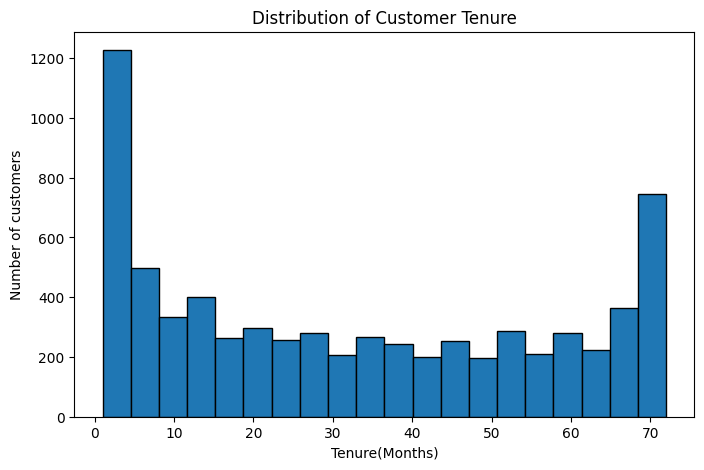

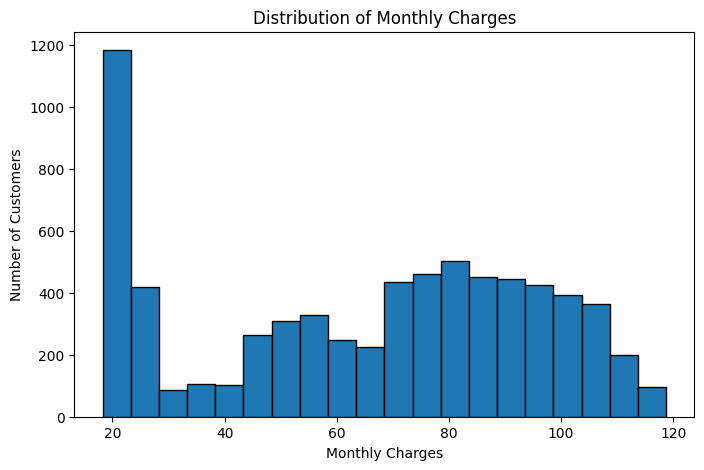

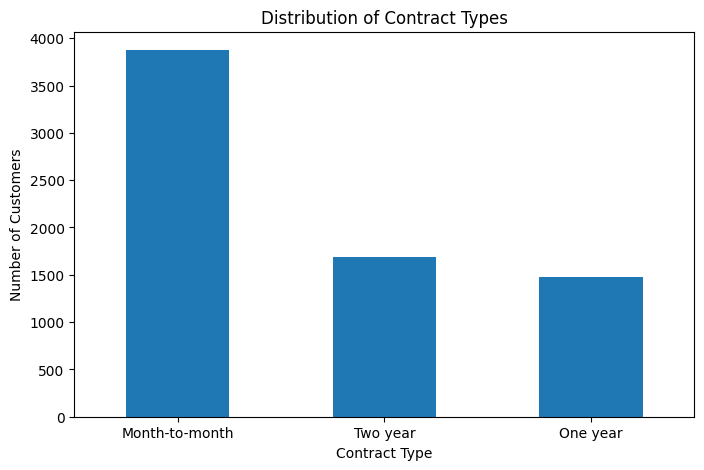

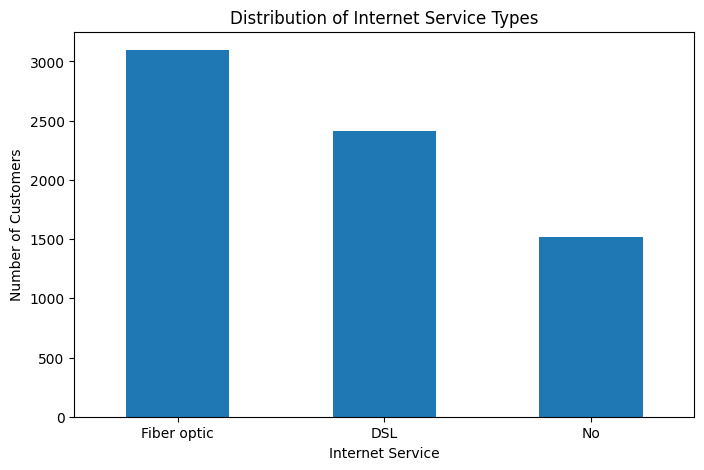

In [9]:
# Task 12
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(cleaned_df["tenure"],bins=20, edgecolor="black")
plt.xlabel("Tenure(Months)")
plt.ylabel("Number of customers")
plt.title("Distribution of Customer Tenure")
plt.show()

# The distribution shows how long customers have stayed with the company. There are many customers with relatively short tenure, while the number of customers generally varies across the longer tenure periods.

plt.figure(figsize=(8, 5))
plt.hist(cleaned_df["MonthlyCharges"], bins=20, edgecolor="black")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.title("Distribution of Monthly Charges")
plt.show()

# Monthly charges are spread across a relatively wide range. The distribution shows that customers pay different monthly amounts rather than being concentrated around a single charge.

plt.figure(figsize=(8,5))
cleaned_df["Contract"].value_counts().plot(kind="bar")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.title("Distribution of Contract Types")
plt.xticks(rotation=0)
plt.show()

# Month-to-month contracts are the most common, while two-year contracts are the least common. This shows that customers are more likely to have flexible, short-term contracts.

plt.figure(figsize=(8, 5))

cleaned_df["InternetService"].value_counts().plot(kind="bar")

plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.title("Distribution of Internet Service Types")
plt.xticks(rotation=0)
plt.show()

# DSL and fiber-optic services make up most of the customers, while customers without internet service form a smaller group. The distribution also shows that fiber-optic users represent a substantial portion of the dataset.


In [11]:
# 13. Do any numerical features show outliers or a skewed distribution? What might explain this? 

numerical_cols=["tenure","MonthlyCharges","TotalCharges"]
print(cleaned_df[numerical_cols].skew())

print("--------Outliers----------")

for col in numerical_cols:
    Q1=cleaned_df[col].quantile(0.25)
    Q3=cleaned_df[col].quantile(0.75)

    IQR=Q3-Q1

    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR

    outliers=cleaned_df[
        (cleaned_df[col]<lower_bound) |
        (cleaned_df[col]>upper_bound)
    ]
    print("Lower Bound:",lower_bound)
    print("Upper Bound:",upper_bound)
    print("Outliers:",len(outliers))

tenure            0.237731
MonthlyCharges   -0.222103
TotalCharges      0.961642
dtype: float64
--------Outliers----------
Lower Bound: -60.0
Upper Bound: 124.0
Outliers: 0
Lower Bound: -45.824999999999996
Upper Bound: 171.27499999999998
Outliers: 0
Lower Bound: -4688.481250000001
Upper Bound: 8884.66875
Outliers: 0


In [15]:
# 14. Report the number and percentage of churned vs. non-churned customers. Is the target balanced or imbalanced?

churn_count=cleaned_df["Churn"].value_counts()

churn_percentage=cleaned_df["Churn"].value_counts(normalize=True)*100

churn_report=pd.DataFrame({
    "Count":churn_count,
    "Percentage":churn_percentage
})

print(churn_report)

# There are 5,169 non-churned customers (73.46%) and 1,863 churned customers (26.54%) in the cleaned dataset. Therefore, the target variable Churn is imbalanced, with non-churned customers forming the majority class. This imbalance should be considered when evaluating the machine-learning model because accuracy alone may not give a complete picture of model performance.

       Count  Percentage
Churn                   
No      5163   73.421502
Yes     1869   26.578498


# Task 15
In 2–3 sentences, explain why class imbalance when a classification model is trained later — do not describe how to fix it, just why it matters.

Class imbalance matters because a classification model may become biased toward the majority class, which in this dataset is Churn = No. As a result, the model could achieve high overall accuracy while still performing poorly at identifying the churned customers, which are often the more important cases to detect.

In [18]:
# Task 16
# Investigate at least 2 categorical features (e.g. Contract, InternetService, PaymentMethod) against Churn. For each, record: Observation / Evidence / Possible Explanation. 

contract_churn=pd.crosstab(
    cleaned_df["Contract"],
    cleaned_df["Churn"]
)

print(contract_churn)

contract_churn_percentage=pd.crosstab(
    cleaned_df["Contract"],
    cleaned_df["Churn"],
    normalize="index"
)*100

print(contract_churn_percentage.round(2))

Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1306   166
Two year        1637    48
Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.72  11.28
Two year        97.15   2.85


In [45]:

Internet_churn=pd.crosstab(
    cleaned_df["InternetService"],
    cleaned_df["Churn"]
)

print(Internet_churn)

Internet_churn_percent=pd.crosstab(
    cleaned_df["InternetService"],
    cleaned_df["Churn"],
    normalize="index"
)*100

print(Internet_churn_percent.round(2))

Churn              No   Yes
InternetService            
DSL              1957   459
Fiber optic      1799  1297
No               1407   113
Churn               No    Yes
InternetService              
DSL              81.00  19.00
Fiber optic      58.11  41.89
No               92.57   7.43


| Feature | Observation | Evidence | Possible Explanation |
|---|---|---|---|
| Contract | Month-to-month customers are more likely to churn. | Month-to-month has a much higher percentage of Churn = Yes than One year and Two year. | Month-to-month customers have less contractual commitment and may find it easier to leave. |
| InternetService | Churn differs across internet-service types, with Fiber optic having higher churn. | Fiber optic has a higher percentage of Churn = Yes than DSL and No. | Differences in pricing, service expectations, or customer experience may contribute to the difference. |

       count       mean  median  min  max
Churn                                    
No      5163  37.650010    38.0    1   72
Yes     1869  17.979133    10.0    1   72


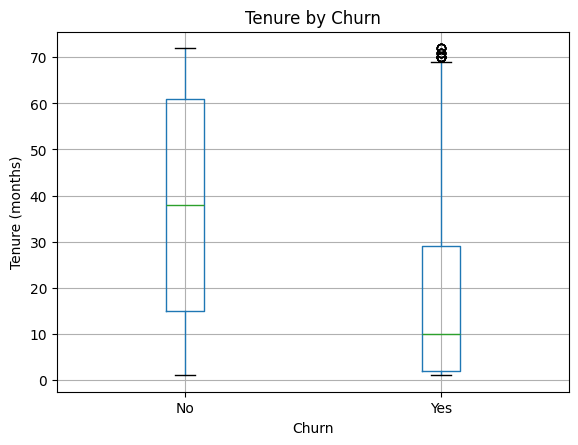

In [23]:
# Task 17: Investigate at least 2 numerical features (e.g. tenure, MonthlyCharges) against Churn using the same Observation / Evidence / Possible Explanation format. 
print(
    cleaned_df.groupby("Churn")["tenure"]
    .agg(["count","mean","median","min","max"]))

import matplotlib.pyplot as plt
cleaned_df.boxplot(
    column="tenure",
    by="Churn"
)
plt.title("Tenure by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure (months)")
plt.show()

       count       mean  median    min     max
Churn                                         
No      5163  61.307408   64.45  18.25  118.75
Yes     1869  74.441332   79.65  18.85  118.35


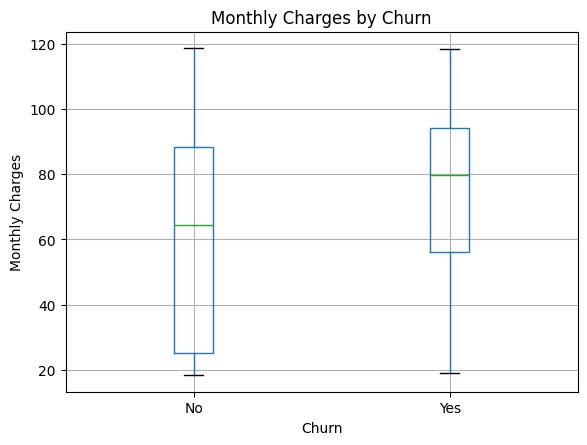

In [27]:
print(
    cleaned_df.groupby("Churn")["MonthlyCharges"]
        .agg(["count","mean","median","min","max"])
)

cleaned_df.boxplot(
    column="MonthlyCharges",
    by="Churn"
)
plt.title("Monthly Charges by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

| Feature | Observation | Evidence | Possible Explanation |
|---|---|---|---|
| `tenure` | Churned customers generally have shorter tenure. | The mean and median tenure for Churn = Yes are lower than for Churn = No. | Newer customers may have less commitment to the company and may leave more easily. |
| `MonthlyCharges` | Churned customers generally have higher monthly charges. | The mean and median MonthlyCharges for Churn = Yes are higher than for Churn = No. | Higher monthly costs may make customers more sensitive to price or consider other providers. |

                SeniorCitizen  tenure  MonthlyCharges  TotalCharges
SeniorCitizen            1.00    0.02            0.22          0.10
tenure                   0.02    1.00            0.25          0.83
MonthlyCharges           0.22    0.25            1.00          0.65
TotalCharges             0.10    0.83            0.65          1.00


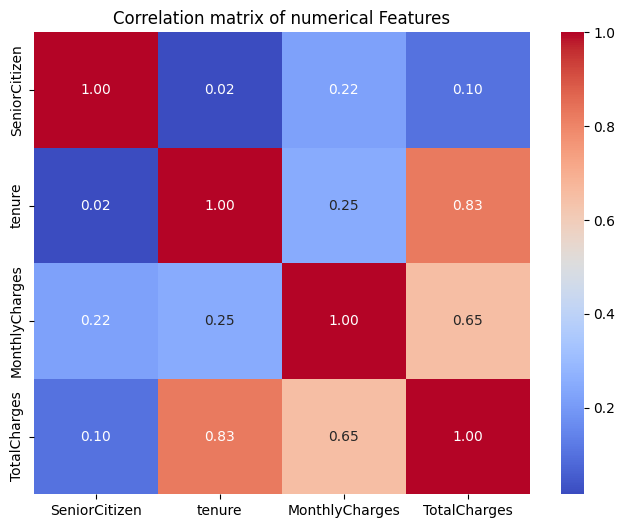

In [31]:
# Task 18: Compute and visualize the correlation matrix of the numerical features. Which pairs appear most correlated? 

numerical_cols=[
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

correlation_matrix=cleaned_df[numerical_cols].corr()
print(correlation_matrix.round(2))

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation matrix of numerical Features")
plt.show()

The correlation matrix shows that tenure and TotalCharges have the strongest positive correlation among the numerical features. This is expected because TotalCharges accumulates over the customer's tenure. MonthlyCharges also has a positive relationship with TotalCharges, since customers paying more per month can accumulate higher total charges.

# Task 19
Does correlation imply causation here? Could any highly correlated features cause problems for a future model? 
Answer in 2–3 sentences. 

Correlation does not imply causation; for example, the strong correlation between tenure and TotalCharges does not mean that one directly causes the other. Highly correlated features can cause problems such as multicollinearity, where a model has difficulty determining the individual contribution of each feature, especially in models such as linear or logistic regression.

# Task 20: 
Inspect the columns for anything that looks like it could only be known after a customer has already churned, or 
that is purely an identifier. List any suspects and explain your reasoning. 

The main identifier suspect is customerID, because it uniquely identifies each customer and does not provide meaningful predictive information. Churn is the target variable rather than a feature, so it must not be included as an input when training the model. There is no obvious post-churn feature in the remaining columns, although TotalCharges should be checked against the prediction time to ensure it does not include information recorded after churn.

# Task 21:
In 2–3 sentences, explain what would go wrong if such a column were left in the model's input features.

If a column containing future information or the target itself is included in the model's input features, the model can learn information that would not actually be available when making a real prediction. This causes data leakage, leading to unrealistically high performance during testing but poor performance when the model is used on new customers.


# Task 22:
 Complete the ML-readiness table for all columns in the dataset — not just the examples shown above. 
| Column | Type | Role | Action | Reason |
|---|---|---|---|---|
| customerID | Identifier | Identifier | Remove | Uniquely identifies each customer but does not provide useful predictive information. |
| gender | Categorical | Feature | Keep | Represents the customer's gender and is available before churn. |
| SeniorCitizen | Numerical (Binary) | Feature | Keep | Indicates whether the customer is a senior citizen; values are 0/1. |
| Partner | Categorical | Feature | Keep | Describes whether the customer has a partner and can be known before churn. |
| Dependents | Categorical | Feature | Keep | Describes whether the customer has dependents. |
| tenure | Numerical | Feature | Keep | Represents the number of months the customer has stayed with the company. |
| PhoneService | Categorical | Feature | Keep | Indicates whether the customer has phone service. |
| MultipleLines | Categorical | Feature | Keep | Describes the customer's multiple-line service status. |
| InternetService | Categorical | Feature | Keep | Describes the type of internet service used by the customer. |
| OnlineSecurity | Categorical | Feature | Keep | Describes whether the customer has online security service. |
| OnlineBackup | Categorical | Feature | Keep | Describes whether the customer has online backup service. |
| DeviceProtection | Categorical | Feature | Keep | Describes whether the customer has device protection service. |
| TechSupport | Categorical | Feature | Keep | Describes whether the customer has technical support service. |
| StreamingTV | Categorical | Feature | Keep | Describes whether the customer uses streaming TV service. |
| StreamingMovies | Categorical | Feature | Keep | Describes whether the customer uses streaming movie service. |
| Contract | Categorical | Feature | Keep | Contract type may provide useful information for predicting churn. |
| PaperlessBilling | Categorical | Feature | Keep | Indicates whether the customer uses paperless billing. |
| PaymentMethod | Categorical | Feature | Keep | Describes how the customer pays for the service. |
| MonthlyCharges | Numerical | Feature | Keep | Represents the customer's monthly charge and is available before prediction. |
| TotalCharges | Numerical | Feature | Clean and Keep | Represents the total amount charged; convert to numeric and handle the blank values before modeling. |
| Churn | Categorical | Target | Keep as Target | This is the outcome to be predicted, so it should not be used as an input feature. |

     

In [46]:
# Task 23
import pandas as pd
import numpy as np

clean_df=df.copy()
clean_df=clean_df.drop(columns=["customerID"])
clean_df["TotalCharges"]=clean_df["TotalCharges"].str.strip()
clean_df["TotalCharges"]=clean_df["TotalCharges"].replace("",np.nan)
clean_df["TotalCharges"]=pd.to_numeric(
    clean_df["TotalCharges"],
    errors="coerce"
)
clean_df=clean_df.dropna(subset=["TotalCharges"])
clean_df=clean_df.drop_duplicates()
clean_df.to_csv("clean_churn.csv",index=False)
print("Dataset cleaned")
print("Shape",clean_df.shape)


Dataset cleaned
Shape (7010, 20)


In [41]:
# Task 24: Print df.info() (or equivalent) for clean_df as final proof that every issue identified earlier has been resolved.
print("\nFinal information:")
clean_df.info()

print("\nMissing values:", clean_df.isnull().sum().sum())
print("Duplicate rows:", clean_df.duplicated().sum())
print("customerID present:", "customerID" in clean_df.columns)
print("TotalCharges dtype:", clean_df["TotalCharges"].dtype)


Final information:
<class 'pandas.DataFrame'>
Index: 7010 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7010 non-null   str    
 1   SeniorCitizen     7010 non-null   int64  
 2   Partner           7010 non-null   str    
 3   Dependents        7010 non-null   str    
 4   tenure            7010 non-null   int64  
 5   PhoneService      7010 non-null   str    
 6   MultipleLines     7010 non-null   str    
 7   InternetService   7010 non-null   str    
 8   OnlineSecurity    7010 non-null   str    
 9   OnlineBackup      7010 non-null   str    
 10  DeviceProtection  7010 non-null   str    
 11  TechSupport       7010 non-null   str    
 12  StreamingTV       7010 non-null   str    
 13  StreamingMovies   7010 non-null   str    
 14  Contract          7010 non-null   str    
 15  PaperlessBilling  7010 non-null   str    
 16  PaymentMethod     7010 non-null   str 

# Task 25: Write your Five Key Findings using the Observation / Evidence / Interpretation format. 

### 1. Month-to-month customers are more likely to churn

* **Observation:** Customers on month-to-month contracts are much more likely to leave.
* **Evidence:** Their churn rate is **42.71%**, compared with **11.28%** for one-year contracts and **2.85%** for two-year contracts.
* **Interpretation:** Customers with long-term contracts are more likely to stay, making month-to-month customers the main group to focus on for retention.

### 2. New customers have a higher risk of churn

* **Observation:** Customers are most likely to churn during their first few months.
* **Evidence:** The churn rate for customers with **0–6 months** of tenure is **53.3%**, compared with only **9.5%** for customers with **49–72 months**.
* **Interpretation:** The early stage of the customer relationship is important. Better onboarding and early support could help reduce churn.

### 3. Customers with higher monthly charges churn more

* **Observation:** Churned customers generally pay more each month.
* **Evidence:** Their average monthly charge is **$74.44**, compared with **$61.31** for customers who stayed.
* **Interpretation:** Higher charges may make customers more likely to question the value they receive or look for cheaper alternatives.

### 4. Fiber-optic customers have a higher churn rate

* **Observation:** Churn differs considerably by internet service type.
* **Evidence:** Fiber-optic customers have a churn rate of **41.89%**, compared with **19.00%** for DSL and **7.43%** for customers without internet service.
* **Interpretation:** Fiber-optic customers are a high-risk group and may need further investigation into pricing, service quality, or customer expectations.

### 5. Electronic-check customers are more likely to churn

* **Observation:** Customers who pay using electronic checks have the highest churn rate among the payment methods.
* **Evidence:** Their churn rate is **45.29%**, compared with **15.25%** for automatic credit-card payments and **16.73%** for automatic bank transfers.
* **Interpretation:** Payment method is a useful signal of churn risk. Electronic-check customers may benefit from targeted retention offers or incentives to switch to automatic payments.


# Task 26: Answer all these.

•  What was the most important data-quality issue you found? 

TotalCharges had blank/non-numeric values, so they needed to be cleaned before analysis.
    
•  What was the most interesting pattern you discovered?

New customers were much more likely to churn than long-term customers, especially within the first 6 months.
    
•  Which feature seems most useful for predicting churn? 
                                   
Contract type seems most useful because churn differs greatly between month-to-month and long-term contracts.
                                   
•  Which feature should probably not be used, and why? 

CustomerID should be excluded because it is just an identifier and has no meaningful relationship with churn.
    
•  What preprocessing will be required before ML modeling (conceptually — do not implement it)? 

Handle missing values, convert categorical variables into numerical form, scale numerical features if needed, and encode the target variable.
•  What would you do next if you had another 3 hours? 

I would build a simple baseline model, train a few ML models, compare their performance, and identify the features that contribute most to churn.